# Импорт библиотек

In [1]:
%pip install -q -U albumentations opencv-python-headless segmentation-models-pytorch ultralytics pandas scikit-learn tqdm pyyaml

Note: you may need to restart the kernel to use updated packages.


In [5]:
import os
import re
import random
import requests
import shutil
import zipfile
from pathlib import Path
from urllib.parse import urlencode

import cv2
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import GroupShuffleSplit

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp
from ultralytics import YOLO

In [2]:
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

torch: 2.10.0
cuda available: False


## Конфиг

In [ ]:
PUBLIC_YANDEX_URL = "https://disk.yandex.ru/d/v3KwZ5UJ8Uoshw"

WORKDIR = Path("./carvana_work")
RAW_DIR = WORKDIR / "raw"
EXTRACT_DIR = WORKDIR / "extracted"
MODEL_DIR = WORKDIR / "models"
YOLO_DIR = WORKDIR / "yolo_dataset"
REPORT_DIR = WORKDIR / "reports"

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
MASK_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".gif"}

for p in [WORKDIR, RAW_DIR, EXTRACT_DIR, MODEL_DIR, YOLO_DIR, REPORT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

SEED = 42
VAL_SIZE = 0.2
DEBUG_MAX_SAMPLES = None
NUM_WORKERS = min(4, os.cpu_count() or 2)

IMG_SIZE = (512, 512)
BATCH_SIZE = 4
EPOCHS = 8
LR = 1e-3

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
ENCODER_NAME = "resnet34"
THRESHOLD = 0.5

RUN_CUSTOM_UNET = False
CUSTOM_UNET_EPOCHS = 6
CUSTOM_BASE_CHANNELS = 32

RUN_YOLO26 = True
YOLO_MODEL_NAME = "yolo26n-seg.pt"
YOLO_IMGSZ = 640
YOLO_EPOCHS = 20
YOLO_BATCH = 8

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = torch.cuda.is_available()
print("device:", device)

device: cpu


In [4]:
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(SEED)

# Загрузка датасета с Yandex Disk

Используется официальный паттерн из документации Yandex Cloud для публичных ресурсов Yandex Disk:
сначала запрашивается `public/resources/download?public_key=...`, затем скачивается URL из поля `href`.

In [6]:
def resolve_yandex_download_url(public_key: str) -> str:
    base_url = "https://cloud-api.yandex.net/v1/disk/public/resources/download?"
    final_url = base_url + urlencode({"public_key": public_key})
    response = requests.get(final_url, timeout=60)
    response.raise_for_status()
    payload = response.json()
    if "href" not in payload:
        raise RuntimeError(f"Yandex Disk did not return direct download link: {payload}")
    return payload["href"]

In [7]:
def download_file(url: str, dst_path: Path, chunk_size: int = 2**20) -> Path:
    dst_path.parent.mkdir(parents=True, exist_ok=True)
    with requests.get(url, stream=True, timeout=120) as r:
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))
        with open(dst_path, "wb") as f, tqdm(total=total, unit="B", unit_scale=True, desc=dst_path.name) as pbar:
            for chunk in r.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)
                    pbar.update(len(chunk))
    return dst_path

In [8]:
def extract_zip(archive_path: Path, dst_dir: Path) -> None:
    dst_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(archive_path, "r") as zf:
        zf.extractall(dst_dir)

In [9]:
outer_archive = RAW_DIR / "carvana-image-masking-challenge.zip"

if not outer_archive.exists():
    direct_url = resolve_yandex_download_url(PUBLIC_YANDEX_URL)
    download_file(direct_url, outer_archive)
else:
    print("Архив уже скачан:", outer_archive)

if not any(EXTRACT_DIR.iterdir()):
    extract_zip(outer_archive, EXTRACT_DIR)
    print("Внешний архив распакован в", EXTRACT_DIR)
else:
    print("Внешний архив уже распакован:", EXTRACT_DIR)

carvana-image-masking-challenge.zip:   0%|          | 0.00/26.5G [00:00<?, ?B/s]

Внешний архив распакован в carvana_work/extracted


In [36]:
def list_files_by_ext(root: Path, exts: set[str]) -> list[Path]:
    return [p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in exts]

In [37]:
def has_enough_pairs(root: Path) -> bool:
    image_files = [p for p in list_files_by_ext(root, IMG_EXTS) if "_mask" not in p.stem.lower()]
    mask_files = [p for p in list_files_by_ext(root, MASK_EXTS) if ("mask" in p.stem.lower() or "mask" in str(p.parent).lower())]
    return len(image_files) > 100 and len(mask_files) > 100

In [38]:
def extract_relevant_inner_archives(root: Path) -> None:
    if has_enough_pairs(root):
        print("Похоже, train-изображения и маски уже доступны, дополнительные zip извлекать не нужно.")
        return

    inner_archives = sorted(root.rglob("*.zip"))
    if not inner_archives:
        print("Вложенных архивов не найдено.")
        return

    def score(path: Path) -> int:
        name = path.name.lower()
        s = 0
        if "train" in name:
            s += 3
        if "mask" in name:
            s += 3
        if "test" in name:
            s -= 5
        if "sample" in name or "submission" in name:
            s -= 3
        return s

    selected = [p for p in inner_archives if score(p) > 0]
    selected = sorted(selected, key=score, reverse=True)

    print("Будут извлечены вложенные архивы:")
    for p in selected:
        print(" -", p)

    for archive_path in selected:
        dst = archive_path.with_suffix("")
        if dst.exists() and any(dst.iterdir()):
            print("Уже извлечён:", dst)
            continue
        print("Извлекаю:", archive_path.name)
        extract_zip(archive_path, dst)

In [39]:
extract_relevant_inner_archives(EXTRACT_DIR)

Похоже, train-изображения и маски уже доступны, дополнительные zip извлекать не нужно.


# Обнаружение структуры датасета и таблица пар `image-mask`

In [40]:
def canonical_image_key(path: Path) -> str:
    return path.stem

In [41]:
def canonical_mask_key(path: Path) -> str:
    return re.sub(r"_mask$", "", path.stem)

In [42]:
def rank_image_path(path: Path) -> tuple:
    s = str(path).lower()
    return (
        int("train_hq" in s),
        int("/train/" in s or "\\train\\" in s or "train" in path.parent.name.lower()),
        path.stat().st_size if path.exists() else 0,
    )

In [43]:
def rank_mask_path(path: Path) -> tuple:
    s = str(path).lower()
    return (
        int("train_masks" in s),
        int("mask" in s),
        path.stat().st_size if path.exists() else 0,
    )

In [55]:
def discover_image_mask_pairs(root: Path) -> pd.DataFrame:
    image_candidates = {}
    for p in list_files_by_ext(root, IMG_EXTS):
        if p.name.startswith("."):
            continue
        if "_mask" in p.stem.lower():
            continue
        image_candidates.setdefault(canonical_image_key(p), []).append(p)

    mask_candidates = {}
    for p in list_files_by_ext(root, MASK_EXTS):
        if p.name.startswith("."):
            continue
        if "mask" not in p.stem.lower() and "mask" not in str(p.parent).lower():
            continue
        mask_candidates.setdefault(canonical_mask_key(p), []).append(p)

    image_map = {k: sorted(v, key=rank_image_path, reverse=True)[0] for k, v in image_candidates.items()}
    mask_map = {k: sorted(v, key=rank_mask_path, reverse=True)[0] for k, v in mask_candidates.items()}

    common_ids = sorted(set(image_map) & set(mask_map))
    if not common_ids:
        raise RuntimeError(
            "Не удалось найти пары image-mask. Проверьте структуру архива после распаковки."
        )

    rows = []
    for sample_id in common_ids:
        image_path = image_map[sample_id]
        mask_path = mask_map[sample_id]
        parts = sample_id.split("_")
        car_id = parts[0]
        angle_id = parts[1] if len(parts) > 1 else None
        rows.append(
            {
                "id": sample_id,
                "car_id": car_id,
                "angle_id": angle_id,
                "image_path": str(image_path),
                "mask_path": str(mask_path),
            }
        )

    df = pd.DataFrame(rows).sort_values("id").reset_index(drop=True)
    return df

In [57]:
df = discover_image_mask_pairs(EXTRACT_DIR)
print("Всего пар image-mask:", len(df))
df.head()

Всего пар image-mask: 105152


,id,car_id,angle_id,image_path,mask_path
0,0004d4463b50_01,0004d4463b50,01,carvana_work/extracted/carvana-image-masking-c...,carvana_work/extracted/carvana-image-masking-c...
1,0004d4463b50_02,0004d4463b50,02,carvana_work/extracted/carvana-image-masking-c...,carvana_work/extracted/carvana-image-masking-c...
2,0004d4463b50_03,0004d4463b50,03,carvana_work/extracted/carvana-image-masking-c...,carvana_work/extracted/carvana-image-masking-c...
3,0004d4463b50_04,0004d4463b50,04,carvana_work/extracted/carvana-image-masking-c...,carvana_work/extracted/carvana-image-masking-c...
4,0004d4463b50_05,0004d4463b50,05,carvana_work/extracted/carvana-image-masking-c...,carvana_work/extracted/carvana-image-masking-c...


In [58]:
if DEBUG_MAX_SAMPLES is not None:
    unique_cars = df["car_id"].drop_duplicates().sample(frac=1.0, random_state=SEED).tolist()
    selected_cars = []
    selected_count = 0
    for car_id in unique_cars:
        car_rows = df[df["car_id"] == car_id]
        if selected_count + len(car_rows) > DEBUG_MAX_SAMPLES and selected_cars:
            break
        selected_cars.append(car_id)
        selected_count += len(car_rows)
    df = df[df["car_id"].isin(selected_cars)].reset_index(drop=True)
    print(f"DEBUG режим: оставлено {len(df)} изображений из {df['car_id'].nunique()} автомобилей")

In [59]:
metadata_files = list(EXTRACT_DIR.rglob("metadata.csv"))
metadata_df = None

In [60]:
if metadata_files:
    metadata_df = pd.read_csv(metadata_files[0])
    print("Найден metadata.csv:", metadata_files[0])
    display(metadata_df.head())
    print("Колонки metadata:", metadata_df.columns.tolist())
else:
    print("metadata.csv не найден — это не мешает обучению.")

Найден metadata.csv: carvana_work/extracted/carvana-image-masking-challenge/metadata.csv


,id,year,make,model,trim1,trim2
0,0004d4463b50,2014.0,Acura,TL,TL,w/SE
1,00087a6bd4dc,2014.0,Acura,RLX,RLX,w/Tech
2,000aa097d423,2012.0,Mazda,MAZDA6,MAZDA6,i Sport
3,000f19f6e7d4,2016.0,Chevrolet,Camaro,Camaro,SS
4,00144e887ae9,2015.0,Acura,TLX,TLX,SH-AWD V6 w/Advance Pkg


Колонки metadata: ['id', 'year', 'make', 'model', 'trim1', 'trim2']


# EDA: размеры изображений, доля foreground, примеры

По данным открытых описаний датасета, в исходном наборе один автомобиль дан в 16 фиксированных ракурсах,
а сами изображения имеют высокое разрешение.

In [61]:
def load_rgb(path: str | Path) -> np.ndarray:
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [62]:
def load_mask(path: str | Path) -> np.ndarray:
    mask = np.array(Image.open(path).convert("L"))
    return mask

In [63]:
def get_image_size(path: str | Path) -> tuple[int, int]:
    with Image.open(path) as img:
        w, h = img.size
    return h, w

In [64]:
size_rows = []
for path in tqdm(df["image_path"], desc="Размеры изображений"):
    h, w = get_image_size(path)
    size_rows.append((h, w))

Размеры изображений:   0%|          | 0/105152 [00:00<?, ?it/s]

In [65]:
sizes_df = pd.DataFrame(size_rows, columns=["height", "width"])
display(sizes_df.describe().T)
print("Уникальные размеры:", sizes_df.drop_duplicates().values.tolist()[:10])

,count,mean,std,min,25%,50%,75%,max
height,105152.0,1280.0,0.0,1280.0,1280.0,1280.0,1280.0,1280.0
width,105152.0,1918.0,0.0,1918.0,1918.0,1918.0,1918.0,1918.0


Уникальные размеры: [[1280, 1918]]


Foreground coverage:   0%|          | 0/256 [00:00<?, ?it/s]

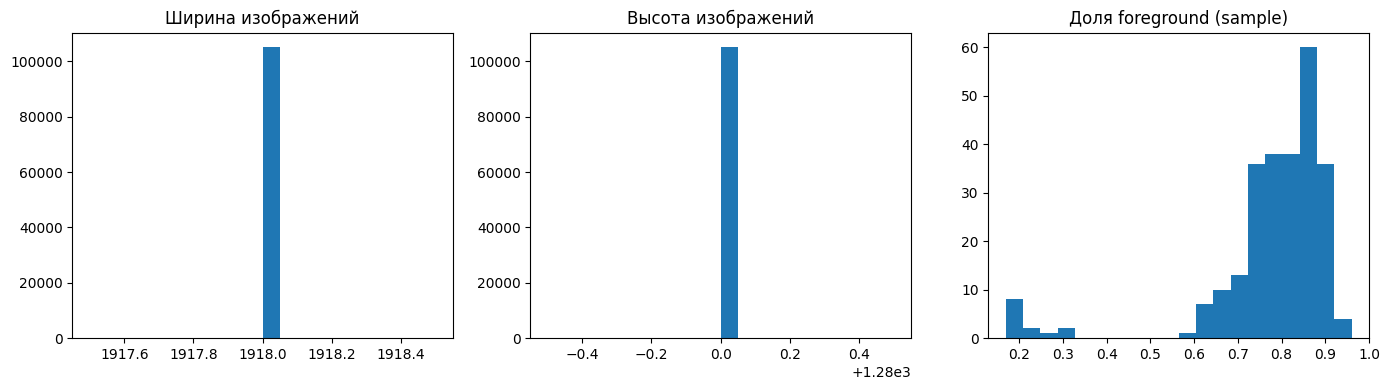

Средняя доля foreground (sample): 0.7791608572006226
Медианная доля foreground (sample): 0.8155843019485474


In [66]:
sample_for_mask_stats = df.sample(min(len(df), 256), random_state=SEED).reset_index(drop=True)

mask_coverages = []
for path in tqdm(sample_for_mask_stats["mask_path"], desc="Foreground coverage"):
    mask = load_mask(path)
    mask_bin = (mask > 127).astype(np.float32)
    mask_coverages.append(mask_bin.mean())

mask_coverages = np.array(mask_coverages)

fig = plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
plt.hist(sizes_df["width"], bins=20)
plt.title("Ширина изображений")

plt.subplot(1, 3, 2)
plt.hist(sizes_df["height"], bins=20)
plt.title("Высота изображений")

plt.subplot(1, 3, 3)
plt.hist(mask_coverages, bins=20)
plt.title("Доля foreground (sample)")
plt.tight_layout()
plt.show()

print("Средняя доля foreground (sample):", float(mask_coverages.mean()))
print("Медианная доля foreground (sample):", float(np.median(mask_coverages)))

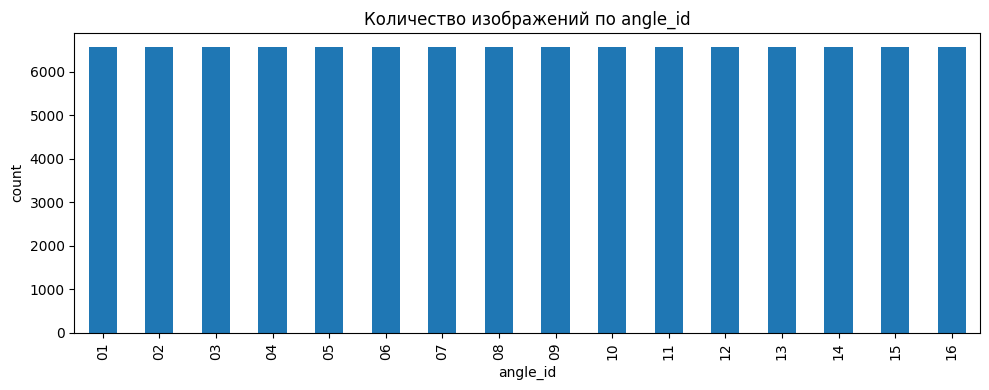

In [67]:
if "angle_id" in df.columns and df["angle_id"].notna().any():
    angle_counts = df["angle_id"].value_counts().sort_index()
    fig = plt.figure(figsize=(10, 4))
    angle_counts.plot(kind="bar")
    plt.title("Количество изображений по angle_id")
    plt.xlabel("angle_id")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

In [68]:
def show_random_samples(df: pd.DataFrame, n: int = 4, seed: int = 42) -> None:
    sample_df = df.sample(min(n, len(df)), random_state=seed).reset_index(drop=True)
    fig, axes = plt.subplots(len(sample_df), 3, figsize=(14, 4 * len(sample_df)))

    if len(sample_df) == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, row in sample_df.iterrows():
        image = load_rgb(row["image_path"])
        mask = load_mask(row["mask_path"])
        mask_bin = (mask > 127).astype(np.uint8)

        overlay = image.copy()
        overlay[mask_bin == 1] = (0.5 * overlay[mask_bin == 1] + 0.5 * np.array([255, 0, 0])).astype(np.uint8)

        axes[i, 0].imshow(image)
        axes[i, 0].set_title(f"Image\n{row['id']}")
        axes[i, 1].imshow(mask_bin, cmap="gray")
        axes[i, 1].set_title("Mask")
        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title("Overlay")

        for j in range(3):
            axes[i, j].axis("off")

    plt.tight_layout()
    plt.show()

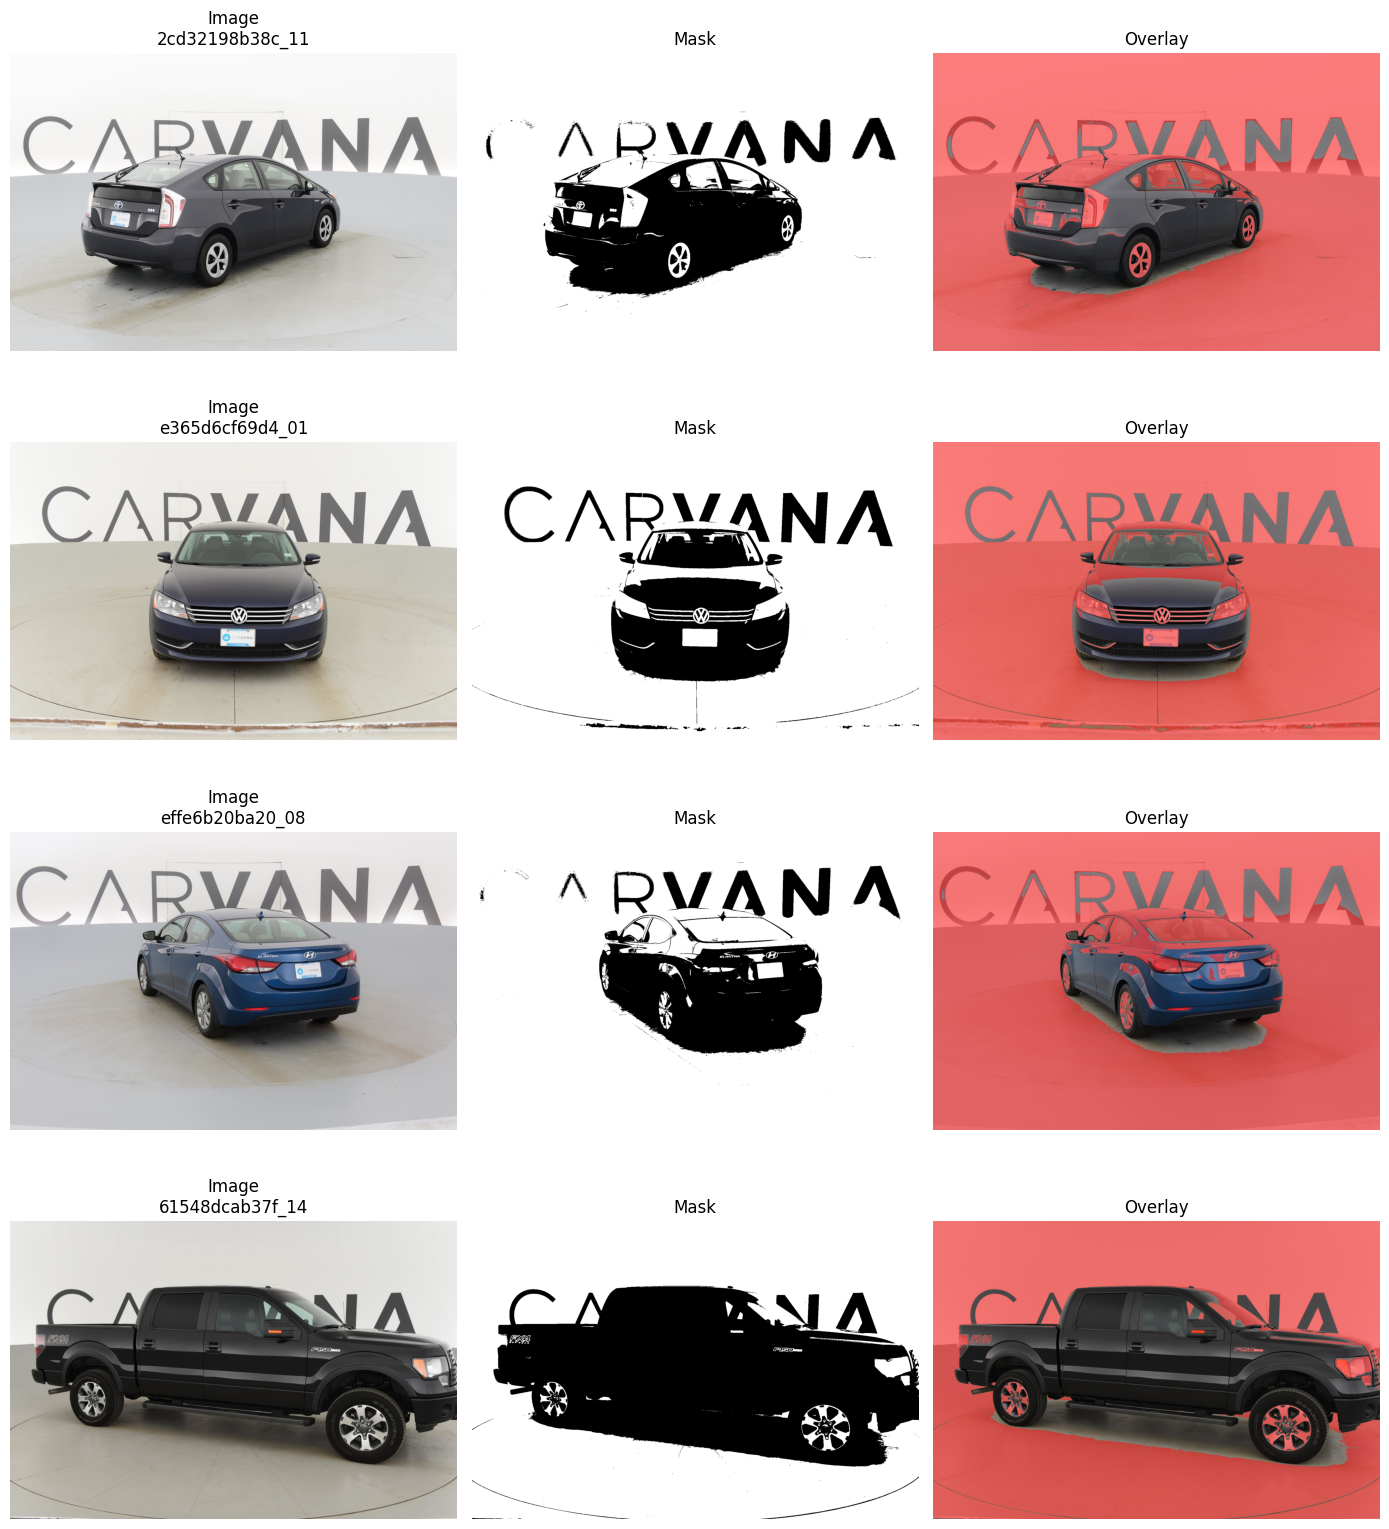

In [69]:
show_random_samples(df, n=4, seed=SEED)

# Train/val split по `car_id`

Это важная деталь. Поскольку один и тот же автомобиль присутствует в 16 ракурсах, случайный split по изображениям
может привести к утечке: тот же автомобиль окажется и в train, и в val. Поэтому split делаем по `car_id`.

In [70]:
splitter = GroupShuffleSplit(n_splits=1, test_size=VAL_SIZE, random_state=SEED)
train_idx, val_idx = next(splitter.split(df, groups=df["car_id"]))

In [71]:
train_df = df.iloc[train_idx].reset_index(drop=True)
val_df = df.iloc[val_idx].reset_index(drop=True)

print("train:", len(train_df), "images,", train_df["car_id"].nunique(), "cars")
print("val:", len(val_df), "images,", val_df["car_id"].nunique(), "cars")
print("Пересечение car_id:", len(set(train_df["car_id"]) & set(val_df["car_id"])))

train: 84112 images, 5257 cars
val: 21040 images, 1315 cars
Пересечение car_id: 0


# Предобработка и аугментация

Требования:
- нормализовать маску;
- уменьшить размер изображений;
- сделать базовую аугментацию: случайный horizontal flip и небольшие повороты;
- аугментация должна быть синхронной для изображения и маски.

Для этого используется **Albumentations**, где геометрические преобразования автоматически применяются к паре `image + mask`.

In [73]:
train_transform = A.Compose(
    [
        A.Resize(IMG_SIZE[0], IMG_SIZE[1]),
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=10, p=0.5, border_mode=cv2.BORDER_CONSTANT),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ]
)

In [74]:
valid_transform = A.Compose(
    [
        A.Resize(IMG_SIZE[0], IMG_SIZE[1]),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ]
)

In [80]:
class CarvanaSegDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, transforms=None):
        self.frame = frame.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        image = load_rgb(row["image_path"])
        mask = load_mask(row["mask_path"])

        mask = (mask > 127).astype(np.float32)

        if self.transforms is not None:
            transformed = self.transforms(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]

            if mask.ndim == 2:
                mask = mask.unsqueeze(0)
            elif mask.ndim == 3 and mask.shape[0] != 1:
                mask = mask[:1]
            mask = mask.float()

        return image, mask

In [82]:
train_ds = CarvanaSegDataset(train_df, transforms=train_transform)
val_ds = CarvanaSegDataset(val_df, transforms=valid_transform)

In [86]:
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

In [87]:
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

In [88]:
xb, yb = next(iter(train_loader))
print("Batch images:", xb.shape, xb.dtype)
print("Batch masks:", yb.shape, yb.dtype, yb.min().item(), yb.max().item())

Batch images: torch.Size([4, 3, 512, 512]) torch.float32
Batch masks: torch.Size([4, 1, 512, 512]) torch.float32 0.0 1.0


In [90]:
def visualize_augmented_batch(dataset: Dataset, n: int = 3):
    fig, axes = plt.subplots(n, 2, figsize=(8, 4 * n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        image_t, mask_t = dataset[i]
        image = image_t.permute(1, 2, 0).cpu().numpy()
        image = (image * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN))
        image = np.clip(image, 0, 1)
        mask = mask_t.squeeze(0).cpu().numpy()

        axes[i, 0].imshow(image)
        axes[i, 0].set_title("Augmented image")
        axes[i, 1].imshow(mask, cmap="gray")
        axes[i, 1].set_title("Augmented mask")
        axes[i, 0].axis("off")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

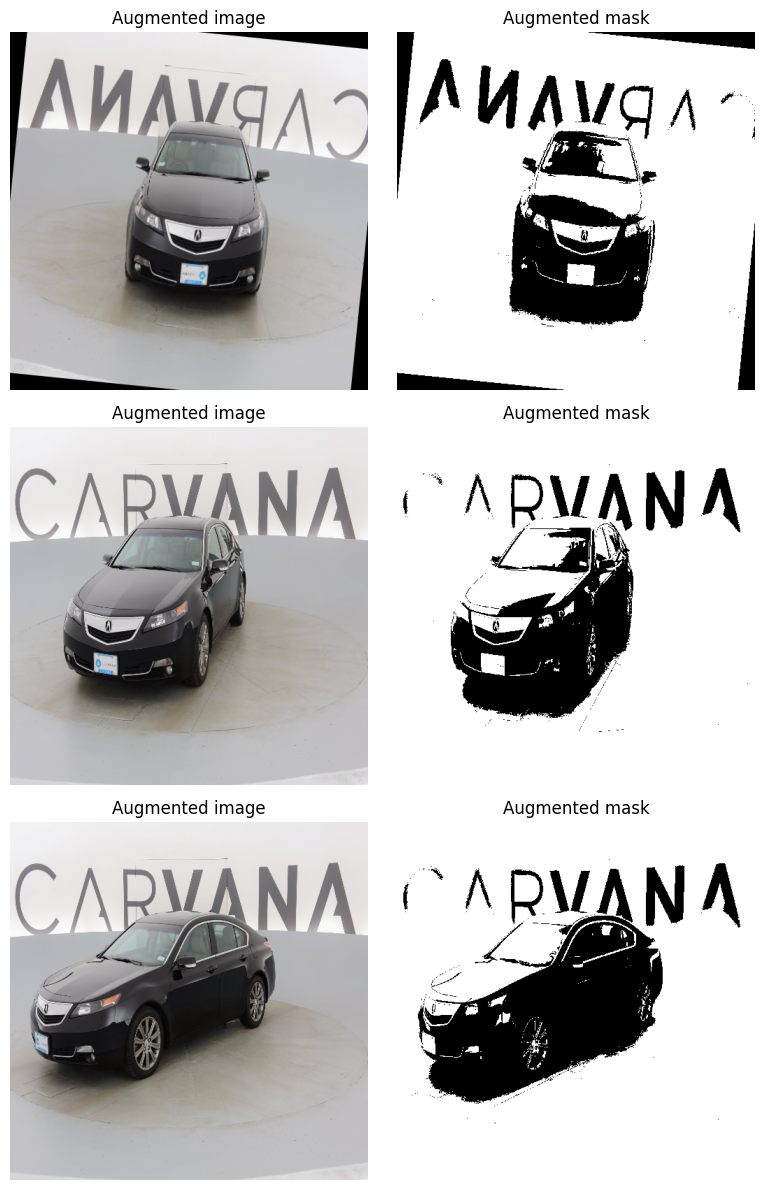

In [91]:
visualize_augmented_batch(train_ds, n=3)

# Обучение

## Функции потерь, метрики и training loop

In [92]:
class DiceLossBinary(nn.Module):
    def __init__(self, smooth: float = 1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        probs = torch.sigmoid(logits)
        dims = (1, 2, 3)
        intersection = (probs * targets).sum(dim=dims)
        denominator = probs.sum(dim=dims) + targets.sum(dim=dims)
        dice = (2.0 * intersection + self.smooth) / (denominator + self.smooth)
        return 1.0 - dice.mean()

In [93]:
bce_loss = nn.BCEWithLogitsLoss()
dice_loss = DiceLossBinary()

In [94]:
def batch_iou_dice_from_logits(
    logits: torch.Tensor,
    targets: torch.Tensor,
    threshold: float = 0.5,
    eps: float = 1e-7,
) -> tuple[float, float]:
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    dims = (1, 2, 3)
    intersection = (preds * targets).sum(dim=dims)
    union = preds.sum(dim=dims) + targets.sum(dim=dims) - intersection
    dice_den = preds.sum(dim=dims) + targets.sum(dim=dims)

    iou = ((intersection + eps) / (union + eps)).mean().item()
    dice = ((2 * intersection + eps) / (dice_den + eps)).mean().item()
    return iou, dice

In [95]:
def make_smp_unet() -> nn.Module:
    model = smp.Unet(
        encoder_name=ENCODER_NAME,
        encoder_weights="imagenet",
        in_channels=3,
        classes=1,
        activation=None,
    )
    return model

In [96]:
def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    loss_fn: nn.Module,
    optimizer: torch.optim.Optimizer | None = None,
    threshold: float = THRESHOLD,
):
    is_train = optimizer is not None
    model.train(is_train)

    scaler = torch.amp.GradScaler("cuda", enabled=use_amp) if is_train else None

    losses = []
    ious = []
    dices = []

    pbar = tqdm(loader, leave=False)
    for images, masks in pbar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=use_amp):
            logits = model(images)
            loss = loss_fn(logits, masks)

        if is_train:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        iou, dice = batch_iou_dice_from_logits(logits.detach(), masks, threshold=threshold)
        losses.append(loss.item())
        ious.append(iou)
        dices.append(dice)

        pbar.set_description(
            f"{'train' if is_train else 'valid'} loss={np.mean(losses):.4f} dice={np.mean(dices):.4f}"
        )

    return {
        "loss": float(np.mean(losses)),
        "iou": float(np.mean(ious)),
        "dice": float(np.mean(dices)),
    }

In [97]:
def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    loss_fn: nn.Module,
    epochs: int,
    lr: float,
    experiment_name: str,
):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=2
    )

    history = []
    best_dice = -np.inf
    best_path = MODEL_DIR / f"{experiment_name}_best.pt"

    for epoch in range(1, epochs + 1):
        train_metrics = run_epoch(model, train_loader, loss_fn, optimizer=optimizer)
        val_metrics = run_epoch(model, val_loader, loss_fn, optimizer=None)

        scheduler.step(val_metrics["dice"])

        row = {
            "epoch": epoch,
            "lr": optimizer.param_groups[0]["lr"],
            "train_loss": train_metrics["loss"],
            "train_iou": train_metrics["iou"],
            "train_dice": train_metrics["dice"],
            "val_loss": val_metrics["loss"],
            "val_iou": val_metrics["iou"],
            "val_dice": val_metrics["dice"],
        }
        history.append(row)

        print(
            f"[{experiment_name}] "
            f"epoch {epoch:02d}/{epochs} | "
            f"train loss={train_metrics['loss']:.4f}, dice={train_metrics['dice']:.4f}, iou={train_metrics['iou']:.4f} | "
            f"val loss={val_metrics['loss']:.4f}, dice={val_metrics['dice']:.4f}, iou={val_metrics['iou']:.4f}"
        )

        if val_metrics["dice"] > best_dice:
            best_dice = val_metrics["dice"]
            torch.save(model.state_dict(), best_path)

    history_df = pd.DataFrame(history)
    history_df.to_csv(REPORT_DIR / f"{experiment_name}_history.csv", index=False)
    return history_df, best_path

## Библиотечная U-Net + BCE

In [98]:
bce_model = make_smp_unet().to(device)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [99]:
bce_history, bce_best_path = train_model(
    model=bce_model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=bce_loss,
    epochs=EPOCHS,
    lr=LR,
    experiment_name="smp_unet_bce",
)

  0%|          | 0/21028 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
display(bce_history.tail())
print("best checkpoint:", bce_best_path)

## 8. Библиотечная U-Net + Dice Loss

In [ ]:
dice_model = make_smp_unet().to(device)
dice_history, dice_best_path = train_model(
    model=dice_model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=dice_loss,
    epochs=EPOCHS,
    lr=LR,
    experiment_name="smp_unet_dice",
)
display(dice_history.tail())
print("best checkpoint:", dice_best_path)

In [ ]:
def plot_histories(histories: dict[str, pd.DataFrame], metric: str = "val_dice"):
    fig = plt.figure(figsize=(8, 4))
    for name, hist in histories.items():
        plt.plot(hist["epoch"], hist[metric], label=name)
    plt.xlabel("epoch")
    plt.ylabel(metric)
    plt.title(metric)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_histories({"BCE": bce_history, "DiceLoss": dice_history}, metric="val_dice")
plot_histories({"BCE": bce_history, "DiceLoss": dice_history}, metric="val_iou")
plot_histories({"BCE": bce_history, "DiceLoss": dice_history}, metric="val_loss")

## 9. Оценка на исходном разрешении: IoU и Dice

Внутри батчей модель обучается на уменьшенных изображениях. Для финальной оценки на валидации:
1. читаем исходное изображение и mask;
2. уменьшаем изображение до `IMG_SIZE`;
3. получаем предсказание модели;
4. масштабируем probability map обратно до исходного разрешения;
5. считаем `IoU` и `Dice` на исходной маске.

In [ ]:
@torch.inference_mode()
def predict_prob_map_unet(model: nn.Module, image_rgb: np.ndarray, image_size: tuple[int, int]) -> np.ndarray:
    transform = A.Compose(
        [
            A.Resize(image_size[0], image_size[1]),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ]
    )
    transformed = transform(image=image_rgb)
    x = transformed["image"].unsqueeze(0).to(device)
    logits = model(x)
    probs = torch.sigmoid(logits)[0, 0].detach().cpu().numpy()
    return probs

def binary_scores(pred_mask: np.ndarray, true_mask: np.ndarray, eps: float = 1e-7) -> tuple[float, float]:
    pred = (pred_mask > 0.5).astype(np.uint8)
    true = (true_mask > 0.5).astype(np.uint8)

    intersection = float((pred & true).sum())
    union = float((pred | true).sum())
    pred_sum = float(pred.sum())
    true_sum = float(true.sum())

    iou = (intersection + eps) / (union + eps)
    dice = (2 * intersection + eps) / (pred_sum + true_sum + eps)
    return iou, dice

@torch.inference_mode()
def evaluate_unet_on_dataframe(model: nn.Module, frame: pd.DataFrame) -> pd.DataFrame:
    model.eval()
    rows = []
    for row in tqdm(frame.itertuples(index=False), total=len(frame), desc="U-Net evaluation"):
        image = load_rgb(row.image_path)
        true_mask = (load_mask(row.mask_path) > 127).astype(np.uint8)

        prob_small = predict_prob_map_unet(model, image, IMG_SIZE)
        prob_full = cv2.resize(
            prob_small,
            (true_mask.shape[1], true_mask.shape[0]),
            interpolation=cv2.INTER_LINEAR,
        )

        iou, dice = binary_scores(prob_full, true_mask)
        rows.append({"id": row.id, "iou": iou, "dice": dice})

    return pd.DataFrame(rows)

best_bce_model = make_smp_unet().to(device)
best_bce_model.load_state_dict(torch.load(bce_best_path, map_location=device))

best_dice_model = make_smp_unet().to(device)
best_dice_model.load_state_dict(torch.load(dice_best_path, map_location=device))

bce_eval_df = evaluate_unet_on_dataframe(best_bce_model, val_df)
dice_eval_df = evaluate_unet_on_dataframe(best_dice_model, val_df)

summary_rows = [
    {"model": "smp_unet_bce", "val_iou_mean": bce_eval_df["iou"].mean(), "val_dice_mean": bce_eval_df["dice"].mean()},
    {"model": "smp_unet_dice", "val_iou_mean": dice_eval_df["iou"].mean(), "val_dice_mean": dice_eval_df["dice"].mean()},
]
summary_df = pd.DataFrame(summary_rows)
display(summary_df.sort_values("val_dice_mean", ascending=False))
summary_df.to_csv(REPORT_DIR / "unet_summary.csv", index=False)

In [ ]:
@torch.inference_mode()
def visualize_model_predictions(model: nn.Module, frame: pd.DataFrame, n: int = 4, seed: int = 42):
    sample = frame.sample(min(n, len(frame)), random_state=seed).reset_index(drop=True)

    fig, axes = plt.subplots(len(sample), 4, figsize=(16, 4 * len(sample)))
    if len(sample) == 1:
        axes = np.expand_dims(axes, axis=0)

    model.eval()
    for i, row in sample.iterrows():
        image = load_rgb(row["image_path"])
        true_mask = (load_mask(row["mask_path"]) > 127).astype(np.uint8)

        prob_small = predict_prob_map_unet(model, image, IMG_SIZE)
        prob_full = cv2.resize(prob_small, (true_mask.shape[1], true_mask.shape[0]), interpolation=cv2.INTER_LINEAR)
        pred_mask = (prob_full > THRESHOLD).astype(np.uint8)

        overlay = image.copy()
        overlay[pred_mask == 1] = (0.5 * overlay[pred_mask == 1] + 0.5 * np.array([255, 0, 0])).astype(np.uint8)

        axes[i, 0].imshow(image)
        axes[i, 0].set_title(f"Image\n{row['id']}")
        axes[i, 1].imshow(true_mask, cmap="gray")
        axes[i, 1].set_title("True mask")
        axes[i, 2].imshow(prob_full, cmap="viridis")
        axes[i, 2].set_title("Pred prob")
        axes[i, 3].imshow(overlay)
        axes[i, 3].set_title("Pred overlay")

        for j in range(4):
            axes[i, j].axis("off")

    plt.tight_layout()
    plt.show()

print("BCE model")
visualize_model_predictions(best_bce_model, val_df, n=3, seed=SEED)

print("Dice model")
visualize_model_predictions(best_dice_model, val_df, n=3, seed=SEED + 1)

## 10. (*) Собственная реализация U-Net по мотивам статьи `U-Net: Convolutional Networks for Biomedical Image Segmentation`

Ниже — компактная реализация U-Net с encoder-decoder структурой и skip connections.
Она не повторяет paper побитово, но сохраняет основной принцип архитектуры.

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class DownBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x):
        return self.conv(self.pool(x))

class UpBlock(nn.Module):
    def __init__(self, in_channels: int, skip_channels: int, out_channels: int):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.conv = DoubleConv(in_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)

class CustomUNet(nn.Module):
    def __init__(self, in_channels: int = 3, out_channels: int = 1, base_channels: int = 32):
        super().__init__()
        self.in_conv = DoubleConv(in_channels, base_channels)
        self.down1 = DownBlock(base_channels, base_channels * 2)
        self.down2 = DownBlock(base_channels * 2, base_channels * 4)
        self.down3 = DownBlock(base_channels * 4, base_channels * 8)
        self.down4 = DownBlock(base_channels * 8, base_channels * 16)
        self.bottleneck = DoubleConv(base_channels * 16, base_channels * 16)

        self.up1 = UpBlock(base_channels * 16, base_channels * 8, base_channels * 8)
        self.up2 = UpBlock(base_channels * 8, base_channels * 4, base_channels * 4)
        self.up3 = UpBlock(base_channels * 4, base_channels * 2, base_channels * 2)
        self.up4 = UpBlock(base_channels * 2, base_channels, base_channels)

        self.out_conv = nn.Conv2d(base_channels, out_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.in_conv(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        xb = self.bottleneck(x5)

        x = self.up1(xb, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        return self.out_conv(x)

custom_unet = CustomUNet(base_channels=CUSTOM_BASE_CHANNELS).to(device)
print("Custom U-Net params:", sum(p.numel() for p in custom_unet.parameters()) / 1e6, "M")

In [ ]:
custom_summary_df = None
custom_best_path = None

if RUN_CUSTOM_UNET:
    custom_model = CustomUNet(base_channels=CUSTOM_BASE_CHANNELS).to(device)
    custom_history, custom_best_path = train_model(
        model=custom_model,
        train_loader=train_loader,
        val_loader=val_loader,
        loss_fn=dice_loss,
        epochs=CUSTOM_UNET_EPOCHS,
        lr=LR,
        experiment_name="custom_unet_dice",
    )

    best_custom_model = CustomUNet(base_channels=CUSTOM_BASE_CHANNELS).to(device)
    best_custom_model.load_state_dict(torch.load(custom_best_path, map_location=device))
    custom_eval_df = evaluate_unet_on_dataframe(best_custom_model, val_df)

    custom_summary_df = pd.DataFrame(
        [
            {
                "model": "custom_unet_dice",
                "val_iou_mean": custom_eval_df["iou"].mean(),
                "val_dice_mean": custom_eval_df["dice"].mean(),
            }
        ]
    )
    display(custom_summary_df)
else:
    print("RUN_CUSTOM_UNET=False — код реализации готов, но обучение пропущено.")

## 11. Как использовать высокое исходное разрешение и что делать с однообразным фоном

### Высокое разрешение
Для Carvana это действительно важно: в открытых разборах соревнования указывается исходное разрешение `1918x1280`,
а лучшие решения часто либо обучались на полном размере, либо использовали двухэтапную схему.

Практичные варианты:

1. **Progressive resizing**  
   сначала обучить на `512x512`, потом дообучить на `768x768` или `1024x1024`;

2. **Coarse-to-fine**  
   сначала предсказывать грубую маску на уменьшенном изображении, затем делать refinement по boundary tiles;

3. **Patch / tile refinement**  
   обучать второй этап только на областях возле границы объекта;

4. **TTA и ансамбли**  
   горизонтальные флипы и усреднение предсказаний по fold'ам.

### Однообразный белый/студийный фон
Это риск того, что модель начнёт сегментировать «фон студии», а не «машину».

Что помогает на практике:

- split по `car_id`, чтобы не получать ложный validation-score из-за утечки;
- Dice или BCE+Dice, так как foreground занимает лишь часть пикселей;
- boundary-aware weighting около границы машины;
- background perturbation: слегка менять яркость/цвет только у background-пикселей;
- hard-example mining для низкоконтрастных случаев;
- отдельно контролировать случаи типа белая машина на белом фоне.

Ниже — пример функции, которая может делать мягкую рандомизацию фона **только в обучении**.

In [ ]:
def perturb_background(image: np.ndarray, mask: np.ndarray, noise_std: float = 10.0) -> np.ndarray:
    img = image.astype(np.float32).copy()
    bg = mask <= 0.5

    noise = np.random.normal(0, noise_std, size=img.shape).astype(np.float32)
    brightness = np.random.uniform(0.9, 1.1)

    img[bg] = img[bg] * brightness + noise[bg]
    img = np.clip(img, 0, 255).astype(np.uint8)
    return img

## 12. YOLO26-seg baseline

YOLO26 относится к **instance segmentation**. Для Carvana у нас один объект класса `car` на изображение,
поэтому можно превратить бинарную mask в polygon labels формата Ultralytics.

Важно: такая конвертация — это **аппроксимация** плотной маски полигонами.
Для очень тонких деталей и дыр внутри маски это может слегка менять задачу по сравнению с raster-бинарной сегментацией U-Net.

In [ ]:
def mask_to_yolo_polygons(mask: np.ndarray, epsilon_ratio: float = 0.001) -> list[list[float]]:
    mask = (mask > 127).astype(np.uint8)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    h, w = mask.shape[:2]
    polygons = []

    for contour in contours:
        if contour.shape[0] < 3:
            continue

        epsilon = epsilon_ratio * cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, epsilon, True)
        points = approx.squeeze(1)

        if points.ndim != 2 or len(points) < 3:
            continue

        poly = []
        for x, y in points:
            poly.extend([float(x) / w, float(y) / h])
        polygons.append(poly)

    return polygons

def hardlink_or_copy(src: Path, dst: Path) -> None:
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists():
        return
    try:
        os.link(src, dst)
    except Exception:
        shutil.copy2(src, dst)

def prepare_yolo_segmentation_dataset(train_df: pd.DataFrame, val_df: pd.DataFrame, yolo_root: Path) -> Path:
    if yolo_root.exists():
        shutil.rmtree(yolo_root)
    (yolo_root / "images" / "train").mkdir(parents=True, exist_ok=True)
    (yolo_root / "images" / "val").mkdir(parents=True, exist_ok=True)
    (yolo_root / "labels" / "train").mkdir(parents=True, exist_ok=True)
    (yolo_root / "labels" / "val").mkdir(parents=True, exist_ok=True)

    def write_split(frame: pd.DataFrame, split_name: str):
        for row in tqdm(frame.itertuples(index=False), total=len(frame), desc=f"YOLO {split_name} prep"):
            src_image = Path(row.image_path)
            dst_image = yolo_root / "images" / split_name / src_image.name
            hardlink_or_copy(src_image, dst_image)

            mask = load_mask(row.mask_path)
            polygons = mask_to_yolo_polygons(mask)

            label_path = yolo_root / "labels" / split_name / f"{src_image.stem}.txt"
            with open(label_path, "w", encoding="utf-8") as f:
                for poly in polygons:
                    line = "0 " + " ".join(f"{v:.6f}" for v in poly)
                    f.write(line + "\n")

    write_split(train_df, "train")
    write_split(val_df, "val")

    data_yaml = {
        "path": str(yolo_root.resolve()),
        "train": "images/train",
        "val": "images/val",
        "names": {0: "car"},
    }

    yaml_path = yolo_root / "carvana_seg.yaml"
    with open(yaml_path, "w", encoding="utf-8") as f:
        yaml.safe_dump(data_yaml, f, sort_keys=False, allow_unicode=True)

    return yaml_path

yolo_yaml_path = prepare_yolo_segmentation_dataset(train_df, val_df, YOLO_DIR)
print("YOLO yaml:", yolo_yaml_path)
print(yolo_yaml_path.read_text(encoding="utf-8"))

In [ ]:
def yolo_result_to_binary_mask(result) -> np.ndarray:
    h, w = result.orig_shape
    pred_mask = np.zeros((h, w), dtype=np.uint8)

    if result.masks is None:
        return pred_mask

    for poly in result.masks.xy:
        pts = np.round(poly).astype(np.int32)
        if len(pts) >= 3:
            cv2.fillPoly(pred_mask, [pts], 1)

    return pred_mask

def find_best_yolo_weight_path(model: YOLO) -> Path:
    trainer = getattr(model, "trainer", None)
    if trainer is None:
        raise RuntimeError("Не удалось получить trainer у YOLO после обучения.")
    best = getattr(trainer, "best", None)
    if best is not None:
        return Path(best)
    save_dir = getattr(trainer, "save_dir", None)
    if save_dir is not None:
        candidate = Path(save_dir) / "weights" / "best.pt"
        if candidate.exists():
            return candidate
    raise RuntimeError("Не удалось найти best.pt после обучения YOLO26.")

@torch.inference_mode()
def evaluate_yolo26_on_dataframe(weight_path: Path, frame: pd.DataFrame) -> pd.DataFrame:
    yolo_model = YOLO(str(weight_path))
    rows = []

    for row in tqdm(frame.itertuples(index=False), total=len(frame), desc="YOLO26 evaluation"):
        result = yolo_model.predict(source=row.image_path, imgsz=YOLO_IMGSZ, verbose=False)[0]
        pred_mask = yolo_result_to_binary_mask(result)
        true_mask = (load_mask(row.mask_path) > 127).astype(np.uint8)

        iou, dice = binary_scores(pred_mask, true_mask)
        rows.append({"id": row.id, "iou": iou, "dice": dice})

    return pd.DataFrame(rows)

In [ ]:
yolo_summary_df = None
yolo_best_path = None

if RUN_YOLO26:
    yolo_model = YOLO(YOLO_MODEL_NAME)
    yolo_model.train(
        data=str(yolo_yaml_path),
        epochs=YOLO_EPOCHS,
        imgsz=YOLO_IMGSZ,
        batch=YOLO_BATCH,
        project=str(MODEL_DIR),
        name="yolo26_seg_carvana",
        exist_ok=True,
        pretrained=True,
    )
    yolo_best_path = find_best_yolo_weight_path(yolo_model)
    print("YOLO best checkpoint:", yolo_best_path)

    yolo_eval_df = evaluate_yolo26_on_dataframe(yolo_best_path, val_df)
    yolo_summary_df = pd.DataFrame(
        [
            {
                "model": "yolo26n-seg",
                "val_iou_mean": yolo_eval_df["iou"].mean(),
                "val_dice_mean": yolo_eval_df["dice"].mean(),
            }
        ]
    )
    display(yolo_summary_df)
else:
    print("RUN_YOLO26=False — подготовка датасета выполнена, обучение пропущено.")

In [ ]:
all_summaries = [summary_df]

if custom_summary_df is not None:
    all_summaries.append(custom_summary_df)
if yolo_summary_df is not None:
    all_summaries.append(yolo_summary_df)

final_summary_df = pd.concat(all_summaries, ignore_index=True)
final_summary_df = final_summary_df.sort_values("val_dice_mean", ascending=False).reset_index(drop=True)
display(final_summary_df)
final_summary_df.to_csv(REPORT_DIR / "all_models_summary.csv", index=False)

## 13. Краткий вывод

Что уже реализовано в ноутбуке:

- загрузка датасета по публичной ссылке Yandex Disk;
- изучение структуры и визуализация данных;
- нормализация mask и уменьшение размера изображений;
- синхронная аугментация image+mask;
- обучение библиотечной U-Net c BCE и Dice Loss;
- оценка через IoU и Dice;
- реализация своей версии U-Net;
- подготовка и запуск YOLO26-seg baseline.

### Что обычно стоит попробовать дальше

- `BCE + Dice` как комбинированную loss;
- progressive resizing;
- boundary-aware sampling / weighting;
- TTA на валидации;
- отдельную обработку low-contrast примеров;
- кросс-валидацию по `car_id`.

## Источники

1. Kaggle Carvana Image Masking Challenge  
   https://www.kaggle.com/competitions/carvana-image-masking-challenge

2. DatasetNinja: Carvana Image Masking 2017  
   https://datasetninja.com/carvana-image-masking

3. Kaggle Blog / Medium: 1st place winner’s interview  
   https://medium.com/kaggle-blog/carvana-image-masking-challenge-1st-place-winners-interview-78fcc5c887a8

4. Yandex Cloud docs: Working with datasets / Yandex Disk public download pattern  
   https://yandex.cloud/en/docs/datasphere/operations/data/dataset

5. Ultralytics YOLO26 docs  
   https://docs.ultralytics.com/models/yolo26/

6. Ultralytics instance segmentation docs  
   https://docs.ultralytics.com/tasks/segment/

7. Ultralytics segmentation dataset format  
   https://docs.ultralytics.com/datasets/segment/

8. U-Net paper  
   https://arxiv.org/abs/1505.04597